In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import os
import pandas as pd

sns.set_theme(font_scale=1.6)
plt.rcParams.update({"text.usetex": True, "font.family": "Modern"})

# Set font to arial
# plt.rcParams["font.family"] = "Arial"

In [2]:
# Path to MLflow runs
mlruns_path = r"C:\Users\user\Repositories\fault-classification-localization\mlruns"

# List to store all run data
all_runs = []

# Iterate through experiments
for exp_id in os.listdir(mlruns_path):
    exp_path = os.path.join(mlruns_path, exp_id)
    if os.path.isdir(exp_path):  # Ensure it's a directory
        for run_id in os.listdir(exp_path):
            run_path = os.path.join(exp_path, run_id)
            if os.path.isdir(run_path):  # Ensure it's a run directory
                run_data = {"run_id": run_id, "experiment_id": exp_id}

                # Read params, metrics, and tags directories
                for subdir in ["params", "metrics", "tags"]:
                    subdir_path = os.path.join(run_path, subdir)
                    if os.path.exists(subdir_path):
                        for file_name in os.listdir(subdir_path):
                            file_path = os.path.join(subdir_path, file_name)
                            with open(file_path, "r", encoding="utf-8") as f:
                                run_data[file_name] = f.read().strip()  # Read content

                all_runs.append(run_data)

# Convert to DataFrame
runs = pd.DataFrame(all_runs)

# Save to CSV
csv_path = os.path.join(mlruns_path, "all_runs.csv")
runs.to_csv(csv_path, index=False)

print(f"Saved combined runs data to: {csv_path}")

Saved combined runs data to: C:\Users\user\Repositories\fault-classification-localization\mlruns\all_runs.csv


In [3]:
runs = pd.DataFrame(
    pd.read_csv(
        r"C:\Users\user\Repositories\fault-classification-localization\mlruns\all_runs.csv"
    )
)

In [4]:
runs

,run_id,experiment_id,dataset,fault_target,model,n_features,n_samples,n_timesteps,n_windows,task_type,...,mlflow.source.git.commit,mlflow.source.name,mlflow.source.type,mlflow.user,mean_mae,mean_r2,mean_rmse,std_mae,std_r2,std_rmse
0,023b2488df8548988df2baec9ac5c34a,358755741528750461,test_dataset_90kv_multi_fault_200_samples,fault_class,ridge_classifier,9216.0,5238.0,192.0,5238.0,classification,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,NaN,NaN,NaN,NaN,NaN,NaN
1,0260cb67dd5a4414abd9c05230ddc8e6,358755741528750461,test_dataset_90kv_multi_fault_200_samples,fault_class,ridge_classifier,15360.0,4462.0,320.0,4462.0,classification,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,NaN,NaN,NaN,NaN,NaN,NaN
2,0328f8c7206148a98b8aff6a9cfebce6,358755741528750461,test_dataset_90kv_multi_fault_200_samples,fault_location,mlp_regressor,15360.0,1746.0,320.0,1746.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752861303587 26.14893238593956 0,1752861304229 -0.18837492191333274 0,1752861304042 32.09493905124605 0,1752861303797 2.8089909863908815 0,1752861304311 0.09253068592191649 0,1752861304126 2.6516546497335134 0
3,035646b83c0f4d18b70a7104bc88d4f8,358755741528750461,test_dataset_90kv_multi_fault_200_samples,fault_location,hist_gradient_boosting_regressor,15360.0,1746.0,320.0,1746.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752861087664 23.64172370655998 0,1752861087963 0.07826433001210793 0,1752861087830 28.35686695734891 0,1752861087798 3.290237559103239 0,1752861088009 0.04420591264255312 0,1752861087896 3.084520332228539 0
4,03581f96e327480fbf66b16fed83ef72,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,ada_boost_classifier,12288.0,225550.0,256.0,225550.0,classification,...,12dd87d0d49bde0c25918e4287db7e6ba7fdebf1,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
205,fea258c0cbed409987b67a3d5a69ae38,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_location,ridge,9216.0,45110.0,192.0,45110.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752873694747 26.064236851516945 0,1752873696246 -0.16309821318463227 0,1752873695415 31.210569706009345 0,1752873694998 0.5990726086595523 0,1752873696660 0.04006580574740342 0,1752873695757 0.7622817030436907 0
206,ff2cccdbef474929bfd09cb39ee6ad2e,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,stacking_classifier,9216.0,243594.0,192.0,243594.0,classification,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,NaN,NaN,NaN,NaN,NaN,NaN
207,ffad960dc95e46349a962ceb26dd7b5e,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_location,sgd_regressor,6144.0,27066.0,128.0,27066.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752875594675 271683610014.604 0,1752875596397 -1.9044555436354057e+20 0,1752875595542 384005460894.9618 0,1752875595030 106207376746.13232 0,1752875596549 1.1570950056570303e+20 0,1752875595799 117974123209.40929 0
208,ffe277f68bc94b31b144663f0dc599f2,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,random_forest_classifier,15360.0,207506.0,320.0,207506.0,classification,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
runs_before = len(runs)
filtered_runs = runs[runs["completed"] == True].copy()

filtered_runs = filtered_runs[
    filtered_runs["dataset"] == "new_double_line_90kv_multi_fault_10k"
]

print(
    f"Total runs: {len(filtered_runs)}. Filtered runs: {runs_before - len(filtered_runs)} removed."
)

Total runs: 100. Filtered runs: 110 removed.


In [6]:
# mapping from raw CSV names to short model labels
model_map = {
    "ridge_classifier": "Ridge",
    "ridge": "Ridge",
    "mlp_classifier": "MLP",
    "mlp_regressor": "MLP",
    "stacking_classifier": "Stacking",
    "stacking_regressor": "Stacking",
    "voting_regressor": "Voting",
    "k_neighbors_classifier": "KNN",
    "k_neighbors_regressor": "KNN",
    "hist_gradient_boosting_classifier": "GB",
    "hist_gradient_boosting_regressor": "GB",
    "logistic_regression": "LG",
    "linear_regression": "LR",
    "linear_svr": "SVR",
    "svr": "SVR",
    "svc": "SVC",
    "decision_tree_classifier": "DT",
    "decision_tree_regressor": "DT",
    "random_forest_classifier": "RF",
    "ada_boost_classifier": "AdaBoost",
    "ada_boost_regressor": "AdaBoost",
    "sgd_regressor": "SGD",
    "extra_trees_classifier": "ET",
    "extra_trees_regressor": "ET",
}

# apply mapping
filtered_runs["model"] = (
    filtered_runs["model"].map(model_map).fillna(filtered_runs["model"])
)

# Convert window_length to milliseconds
filtered_runs["window_length"] = filtered_runs["window_length"] * 1000  # convert to ms
filtered_runs["window_length"] = filtered_runs["window_length"].astype(int)

In [7]:
# Create two dataframes by task_type
classification_runs = filtered_runs[filtered_runs["task_type"] == "classification"]
regression_runs = filtered_runs[filtered_runs["task_type"] == "localization"]


print("Classification runs:")
print(classification_runs.shape)

print("Regression runs:")
print(regression_runs.shape)

Classification runs:
(40, 30)
Regression runs:
(60, 30)


In [8]:
# drop *_mae, *_mse, *_rmse, *_r2 columns
mask = ~classification_runs.columns.str.endswith(("_mae", "_mse", "_rmse", "_r2"))
classification_runs = classification_runs.loc[:, mask]

# drop *_f1_score, *_accuracy, *_precision, *_recall columns from regression runs
regression_mask = ~regression_runs.columns.str.endswith(
    ("_f1_score", "_accuracy", "_precision", "_recall")
)
regression_runs = regression_runs.loc[:, regression_mask]

# print new shapes
print("Classification runs after dropping metrics:")
print(classification_runs.shape)
print("Regression runs after dropping metrics:")
print(regression_runs.shape)

Classification runs after dropping metrics:
(40, 24)
Regression runs after dropping metrics:
(60, 24)


In [9]:
regression_runs

,run_id,experiment_id,dataset,fault_target,model,n_features,n_samples,n_timesteps,n_windows,task_type,...,mlflow.source.git.commit,mlflow.source.name,mlflow.source.type,mlflow.user,mean_mae,mean_r2,mean_rmse,std_mae,std_r2,std_rmse
7,071ff9ea4b074be3b53b708d8fdf30dd,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_location,KNN,15360.0,81198.0,320.0,81198.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752868205244 19.155187616444103 0,1752868205859 0.3306403871267106 0,1752868205611 23.67627088106617 0,1752868205448 0.3042536688073035 0,1752868206075 0.010008103606419112 0,1752868205722 0.19845566188471184 0
13,0afd55a4c63841aea14d7ce23142cfbf,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_location,Stacking,15360.0,81198.0,320.0,81198.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752910674207 9.761051216382508 0,1752910675061 0.799089959242575 0,1752910674700 12.971919559035644 0,1752910674589 0.2802903389527596 0,1752910675188 0.008323067785096047 0,1752910674754 0.3920350610824802 0
14,0c9aa321500e41d3a257365106ad94a9,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_location,SVR,6144.0,27066.0,128.0,27066.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752906783540 26.211480949216394 0,1752906783850 -0.20444074520846076 0,1752906783816 31.763084474782023 0,1752906783808 0.47203898446361287 0,1752906783864 0.016371893652109414 0,1752906783830 0.5179401165457429 0
18,1143b42281e84215abbc47001d61b05a,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_location,AdaBoost,15360.0,81198.0,320.0,81198.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752912181597 24.962740062061386 0,1752912182617 0.006836352102698173 0,1752912182304 28.841700761747898 0,1752912182069 0.3397584308539557 0,1752912182854 0.005014609833695552 0,1752912182533 0.28153989763791615 0
19,1148301a804d48f382572e1b054cfefa,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_location,SGD,9216.0,45110.0,192.0,45110.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752875379002 434502824063.9553 0,1752875379569 -4.5022249554474736e+20 0,1752875379332 609953139944.7615 0,1752875379181 73886494303.32277 0,1752875379781 1.056531929661604e+20 0,1752875379450 72930213129.81194 0
21,12e1259da593498da79581ad2c10bbb2,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_location,Voting,9216.0,45110.0,192.0,45110.0,localization,...,12dd87d0d49bde0c25918e4287db7e6ba7fdebf1,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1753183673407 10.645302429051654 0,1753183673420 0.7681591386693036 0,1753183673415 13.933187317523274 0,1753183673412 0.10655600897711624 0,1753183673423 0.005338758796593104 0,1753183673418 0.13509207605727983 0
22,14168a1ee860439ebf33ec061eebb410,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_location,GB,3072.0,9022.0,64.0,9022.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752864441675 14.620671357114583 0,1752864441684 0.5979426837516642 0,1752864441680 18.34870773945222 0,1752864441678 0.2243482601981437 0,1752864441685 0.008008360579775171 0,1752864441682 0.1363545124435595 0
23,1426c8004fec4976874a94d33cc915dd,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_location,LR,9216.0,45110.0,192.0,45110.0,localization,...,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h,1752869779316 27.0584600634373 0,1752869780814 -0.307758837091599 0,1752869780109 33.09224092114319 0,1752869779837 0.4478604535430648 0,1752869781035 0.04028993255101281 0,1752869780342 0.6116556393067206 0
26,1682ea92fe4d4f9196f70e5883557f8f,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_l

In [10]:
# Update metrics columns
# Format: 1725298761168 0.9992621141359006 0
# convert to str
classification_runs["mean_f1_score"] = classification_runs["mean_f1_score"].astype(str)
# Only keep the second value
classification_runs["mean_f1_score"] = classification_runs["mean_f1_score"].apply(
    lambda x: float(x.split()[1])
)
# convert to float

regression_runs["mean_r2"] = regression_runs["mean_r2"].astype(str)
# Only keep the second value
regression_runs["mean_r2"] = regression_runs["mean_r2"].apply(
    lambda x: float(x.split()[1])
)

# now convert mean_mae to float
regression_runs["mean_mae"] = regression_runs["mean_mae"].astype(str)
regression_runs["mean_mae"] = regression_runs["mean_mae"].apply(
    lambda x: float(x.split()[1])
)
regression_runs["mean_mae"] = regression_runs["mean_mae"].astype(float)

# now for std_mae
regression_runs["std_mae"] = regression_runs["std_mae"].astype(str)
regression_runs["std_mae"] = regression_runs["std_mae"].apply(
    lambda x: float(x.split()[1])
)
regression_runs["std_mae"] = regression_runs["std_mae"].astype(float)

# now std_f1_score for classification
classification_runs["std_f1_score"] = classification_runs["std_f1_score"].astype(str)
classification_runs["std_f1_score"] = classification_runs["std_f1_score"].apply(
    lambda x: float(x.split()[1])
)
classification_runs["std_f1_score"] = classification_runs["std_f1_score"].astype(float)

In [11]:
# Step 1: Drop columns that have all NaN values
classification_runs = classification_runs.dropna(axis=1, how="all")

# Step 2: Drop columns that have any NaN values
classification_runs = classification_runs.dropna(axis=0, how="any")

classification_runs["mean_f1_score"] = pd.to_numeric(
    classification_runs["mean_f1_score"]
)
classification_runs["window_length"] = pd.to_numeric(
    classification_runs["window_length"]
).astype(int)
classification_runs["task_type"] = classification_runs["task_type"].astype("object")
classification_runs["model"] = classification_runs["model"].astype("object")

print(f"Shape of runs after cleaning: {classification_runs.shape}")

Shape of runs after cleaning: (40, 24)


In [12]:
classification_runs.sort_values(by="mean_f1_score")

,run_id,experiment_id,dataset,fault_target,model,n_features,n_samples,n_timesteps,n_windows,task_type,...,std_f1_score,std_precision,std_recall,completed,mlflow.log-model.history,mlflow.runName,mlflow.source.git.commit,mlflow.source.name,mlflow.source.type,mlflow.user
20,12c06fb8621c493aa7ea73033353d05a,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,LG,15360.0,207506.0,320.0,207506.0,classification,...,0.000691,1752899748460 0.12047114755088194 0,1752899748652 0.0003473822519511408 0,True,"[{""run_id"": ""12c06fb8621c493aa7ea73033353d05a""...",skittish-vole-372,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h
12,0a3d617de892488fa9e850a3ebb70251,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,LG,12288.0,225550.0,256.0,225550.0,classification,...,0.001064,1752905086533 0.14888985765909546 0,1752905087045 0.0005361736742417031 0,True,"[{""run_id"": ""0a3d617de892488fa9e850a3ebb70251""...",awesome-croc-188,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h
112,7eb9d56154f84d9b8602f668983ed69f,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,LG,9216.0,243594.0,192.0,243594.0,classification,...,0.001467,1752908251664 0.1582807459566077 0,1752908252372 0.0007377917327497838 0,True,"[{""run_id"": ""7eb9d56154f84d9b8602f668983ed69f""...",melodic-seal-110,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h
68,45f31640102e4f10a48c682fed92e493,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,Ridge,15360.0,207506.0,320.0,207506.0,classification,...,0.003340,1752902692704 0.028293393430563724 0,1752902692709 0.0017529441337409872 0,True,"[{""run_id"": ""45f31640102e4f10a48c682fed92e493""...",auspicious-cat-944,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h
135,a0c88b4cd9de4d36805a79603f3ffe42,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,LG,6144.0,261638.0,128.0,261638.0,classification,...,0.001200,1752910745762 0.12739558397991768 0,1752910745781 0.0006062608518420475 0,True,"[{""run_id"": ""a0c88b4cd9de4d36805a79603f3ffe42""...",bold-fowl-863,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h
143,ad7ea113c491470c9086da77f7811a60,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,Ridge,12288.0,225550.0,256.0,225550.0,classification,...,0.003217,1752905535964 0.027322448289663646 0,1752905536034 0.001675021375234278 0,True,"[{""run_id"": ""ad7ea113c491470c9086da77f7811a60""...",shivering-kite-913,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h
138,a59301703ebe483aa7dc602b7356c528,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,Ridge,9216.0,243594.0,192.0,243594.0,classification,...,0.003099,1752907429244 0.02981020445378988 0,1752907429599 0.0016057594811571103 0,True,"[{""run_id"": ""a59301703ebe483aa7dc602b7356c528""...",merciful-deer-667,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h
80,533f4896f04448698b11ba65ef9113a3,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,Ridge,6144.0,261638.0,128.0,261638.0,classification,...,0.002849,1752908412927 0.03924778639557067 0,1752908413144 0.001472635869730969 0,True,"[{""run_id"": ""533f4896f04448698b11ba65ef9113a3""...",nosy-duck-718,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h
153,b899419d70674d3199a7ae10caafe3fb,358755741528750461,new_double_line_90kv_multi_fault_10k,fault_class,ET,3072.0,279682.0,64.0,279682.0,classification,...,0.002927,1752895235074 0.036365685931730354 0,1752895235079 0.001589725383668902 0,True,"[{""run_id"": ""b899419d70674d3199a7ae10caafe3fb""...",melodic-ant-796,bae20a7e50ad4d6bf7b40b99d0fac9b4f5430cde,src/fcl_psp/models/run_model.py,LOCAL,iwi5217h
132,9da64aefb5dd4d73aa696c00abc0ef3d,358755741528750461,new

## Tables

In [13]:
import numpy as np
import pandas as pd


def export_neurips_fc_main(
    classification_runs: pd.DataFrame,
    *,
    window_col="window_length",
    model_col="model",
    mean_col="mean_f1_score",
    aggfunc="max",
    round_nd=2,
):
    # --------------------------------------------------
    # 1) Pivot: window x model → mean F1
    # --------------------------------------------------
    mean_piv = classification_runs.pivot_table(
        index=window_col,
        columns=model_col,
        values=mean_col,
        aggfunc=aggfunc,
    ).astype(float)

    # --------------------------------------------------
    # 2) Sort windows descending (50 → 10 ms)
    # --------------------------------------------------
    mean_piv = mean_piv.reindex(
        sorted(mean_piv.index, key=lambda x: float(x), reverse=True)
    )

    # --------------------------------------------------
    # 3) Sort models by ASCENDING average mean F1
    # --------------------------------------------------
    model_order = mean_piv.mean(axis=0).sort_values(ascending=True).index
    mean_piv = mean_piv[model_order]

    # --------------------------------------------------
    # 4) NeurIPS layout: models x windows
    # --------------------------------------------------
    table_num = mean_piv.T
    table_num.columns = [f"{int(float(c))} ms" for c in table_num.columns]

    # --------------------------------------------------
    # 5) Compute best-per-column mask (numeric only)
    # --------------------------------------------------
    best_mask = table_num.eq(table_num.max(axis=0), axis=1)

    # --------------------------------------------------
    # 6) Format to strings + LaTeX bold
    # --------------------------------------------------
    def fmt(v, is_best):
        if pd.isna(v):
            return "--"
        s = f"{v:.{round_nd}f}"
        return rf"\textbf{{{s}}}" if is_best else s

    table_str = pd.DataFrame(
        {
            col: [fmt(v, best_mask.loc[row, col]) for row, v in table_num[col].items()]
            for col in table_num.columns
        },
        index=table_num.index,
    )

    # --------------------------------------------------
    # 7) Header fix
    # --------------------------------------------------
    table_str.index.name = "Model"

    return table_str


import pandas as pd


def export_neurips_fc_appendix(
    classification_runs: pd.DataFrame,
    *,
    window_col="window_length",
    model_col="model",
    mean_col="mean_f1_score",
    std_col="std_f1_score",
    aggfunc="max",
    mean_nd=3,
    std_nd=3,
    include_std=True,  # appendix: mean ± std (recommended)
    models_sorted_by_mean=True,  # order models by average mean F1
    sort_windows_desc=True,  # 50 → 10 ms
):
    """
    Appendix table for fault classification (F1):
      - rows = horizons (window_length)
      - columns = models ordered by average mean F1 (ascending=False = best on the left)
      - values = mean or mean ± std

    Matches your "Table 3" style.
    """

    df = classification_runs.copy()

    # ---- pivot mean (and std if requested) ----
    mean_piv = df.pivot_table(
        index=window_col,
        columns=model_col,
        values=mean_col,
        aggfunc=aggfunc,
    ).astype(float)

    std_piv = None
    if include_std:
        std_piv = df.pivot_table(
            index=window_col,
            columns=model_col,
            values=std_col,
            aggfunc=aggfunc,
        ).astype(float)

    # ---- sort windows ----
    mean_piv = mean_piv.reindex(
        sorted(mean_piv.index, key=lambda x: float(x), reverse=sort_windows_desc)
    )
    if include_std:
        std_piv = std_piv.reindex(mean_piv.index)

    # ---- sort models by average mean F1 (best first, i.e., descending) ----
    if models_sorted_by_mean:
        model_order = mean_piv.mean(axis=0).sort_values(ascending=False).index
        mean_piv = mean_piv[model_order]
        if include_std:
            std_piv = std_piv[model_order]

    # ---- format cells ----
    if include_std:
        table = (
            mean_piv.map(lambda x: f"{x:.{mean_nd}f}" if pd.notna(x) else "--")
            + r" $\pm$ "
            + std_piv.map(lambda x: f"{x:.{std_nd}f}" if pd.notna(x) else "--")
        )
    else:
        table = mean_piv.map(lambda x: f"{x:.{mean_nd}f}" if pd.notna(x) else "--")

    # ---- pretty index and header ----
    table.index = [f"{int(float(w))} ms" for w in table.index]
    table.index.name = "Window"

    return table

In [14]:
table_str = export_neurips_fc_main(classification_runs, round_nd=2)
fc_app = export_neurips_fc_appendix(classification_runs, include_std=True)


latex = table_str.to_latex(
    escape=False,
    column_format="l" + "c" * table_str.shape[1],
    multicolumn=True,
    multicolumn_format="c",
)

print(latex)

latex = fc_app.to_latex(
    escape=False,
    column_format="l" + "c" * fc_app.shape[1],
)
print(latex)

\begin{tabular}{lccccc}
\toprule
 & 50 ms & 40 ms & 30 ms & 20 ms & 10 ms \\
Model &  &  &  &  &  \\
\midrule
LG & 0.07 & 0.08 & 0.08 & 0.09 & 0.10 \\
Ridge & 0.09 & 0.09 & 0.09 & 0.10 & 0.10 \\
ET & 0.44 & 0.31 & 0.21 & 0.15 & 0.10 \\
AdaBoost & 0.42 & 0.34 & 0.28 & 0.23 & 0.16 \\
RF & 0.84 & 0.83 & 0.80 & 0.77 & 0.28 \\
KNN & 0.86 & 0.85 & 0.82 & 0.79 & 0.73 \\
GB & 0.98 & 0.98 & 0.98 & 0.75 & 0.42 \\
MLP & \textbf{0.99} & \textbf{0.99} & \textbf{0.99} & \textbf{0.98} & \textbf{0.97} \\
\bottomrule
\end{tabular}

\begin{tabular}{lcccccccc}
\toprule
model & MLP & GB & KNN & RF & AdaBoost & ET & Ridge & LG \\
Window &  &  &  &  &  &  &  &  \\
\midrule
50 ms & 0.989 $\pm$ 0.003 & 0.982 $\pm$ 0.002 & 0.862 $\pm$ 0.003 & 0.838 $\pm$ 0.004 & 0.422 $\pm$ 0.010 & 0.445 $\pm$ 0.026 & 0.087 $\pm$ 0.003 & 0.070 $\pm$ 0.001 \\
40 ms & 0.989 $\pm$ 0.002 & 0.982 $\pm$ 0.002 & 0.847 $\pm$ 0.003 & 0.829 $\pm$ 0.004 & 0.345 $\pm$ 0.011 & 0.306 $\pm$ 0.012 & 0.090 $\pm$ 0.003 & 0.078 $\pm$ 0.001 \\
30

In [15]:
import numpy as np
import pandas as pd


def export_neurips_fl_main(
    regression_runs: pd.DataFrame,
    *,
    window_col="window_length",
    model_col="model",
    mean_col="mean_mae",
    std_col="std_mae",  # kept for symmetry; not used in main table
    aggfunc="max",
    round_nd=2,
    lower_is_better=True,  # MAE: lower is better
    convert_m_to_km=False,  # set True if MAE is in meters and you want km
):
    """
    NeurIPS-main table for fault localization (regression):
      - rows = models
      - columns = decision horizons (50→10 ms)
      - values = mean MAE
      - models sorted by ASCENDING average mean MAE (best at top)
      - best per column in bold (lowest MAE)
      - formatting: round_nd decimals
    """

    df = regression_runs.copy()

    # Optional unit conversion
    scale = 1e-3 if convert_m_to_km else 1.0
    df[mean_col] = df[mean_col].astype(float) * scale

    # --------------------------------------------------
    # 1) Pivot: window x model → mean MAE
    # --------------------------------------------------
    mean_piv = df.pivot_table(
        index=window_col,
        columns=model_col,
        values=mean_col,
        aggfunc=aggfunc,
    ).astype(float)

    # --------------------------------------------------
    # 2) Sort windows descending (50 → 10 ms)
    # --------------------------------------------------
    mean_piv = mean_piv.reindex(
        sorted(mean_piv.index, key=lambda x: float(x), reverse=True)
    )

    # --------------------------------------------------
    # 3) Sort models by ASCENDING average mean MAE (best first)
    # --------------------------------------------------
    ascending_order = not lower_is_better
    model_order = mean_piv.mean(axis=0).sort_values(ascending=ascending_order).index
    mean_piv = mean_piv[model_order]

    # --------------------------------------------------
    # 4) NeurIPS layout: models x windows
    # --------------------------------------------------
    table_num = mean_piv.T
    table_num.columns = [f"{int(float(c))} ms" for c in table_num.columns]

    # --------------------------------------------------
    # 5) Compute best-per-column mask (numeric only)
    #    For MAE: best = MIN per column
    # --------------------------------------------------
    if lower_is_better:
        best_mask = table_num.eq(table_num.min(axis=0), axis=1)
    else:
        best_mask = table_num.eq(table_num.max(axis=0), axis=1)

    # --------------------------------------------------
    # 6) Format to strings + LaTeX bold
    # --------------------------------------------------
    def fmt(v, is_best):
        if pd.isna(v):
            return "--"
        s = f"{v:.{round_nd}f}"
        return rf"\textbf{{{s}}}" if is_best else s

    table_str = pd.DataFrame(
        {
            col: [fmt(v, best_mask.loc[row, col]) for row, v in table_num[col].items()]
            for col in table_num.columns
        },
        index=table_num.index,
    )

    # --------------------------------------------------
    # 7) Header fix
    # --------------------------------------------------
    table_str.index.name = "Model"

    return table_str


def export_neurips_fl_appendix(
    regression_runs: pd.DataFrame,
    *,
    window_col="window_length",
    model_col="model",
    mean_col="mean_mae",
    std_col="std_mae",
    aggfunc="max",
    mean_nd=2,
    std_nd=2,
    convert_m_to_km=False,
    include_std=True,  # appendix: mean ± std
    models_sorted_by_mean=True,  # same “Table 3 style” ordering
):
    """
    Appendix table for FL:
      - rows = horizons (50→10 ms)
      - columns = models ordered by average mean MAE (ascending = best on the left)
      - values = mean or mean ± std
    """
    df = regression_runs.copy()
    scale = 1e-3 if convert_m_to_km else 1.0
    df[mean_col] = df[mean_col].astype(float) * scale
    df[std_col] = df[std_col].astype(float) * scale

    mean_piv = df.pivot_table(
        index=window_col, columns=model_col, values=mean_col, aggfunc=aggfunc
    ).astype(float)

    std_piv = df.pivot_table(
        index=window_col, columns=model_col, values=std_col, aggfunc=aggfunc
    ).astype(float)

    # windows descending
    mean_piv = mean_piv.reindex(
        sorted(mean_piv.index, key=lambda x: float(x), reverse=True)
    )
    std_piv = std_piv.reindex(mean_piv.index)

    # model order: best (lowest MAE) first
    if models_sorted_by_mean:
        model_order = mean_piv.mean(axis=0).sort_values(ascending=True).index
        mean_piv = mean_piv[model_order]
        std_piv = std_piv[model_order]

    # format
    if include_std:
        table = (
            mean_piv.map(lambda x: f"{x:.{mean_nd}f}" if pd.notna(x) else "--")
            + r" $\pm$ "
            + std_piv.map(lambda x: f"{x:.{std_nd}f}" if pd.notna(x) else "--")
        )
    else:
        table = mean_piv.map(lambda x: f"{x:.{mean_nd}f}" if pd.notna(x) else "--")

    table.index = [f"{int(float(w))} ms" for w in table.index]
    table.index.name = "Window"

    return table

In [16]:
models_to_exclude = ["SGD", "LR", "SVR", "Ridge"]

filtered_regression_runs = regression_runs[
    ~regression_runs["model"].isin(models_to_exclude)
]

fl_main = export_neurips_fl_main(
    filtered_regression_runs, round_nd=2, convert_m_to_km=False
)
fl_app = export_neurips_fl_appendix(
    filtered_regression_runs, mean_nd=3, std_nd=3, convert_m_to_km=False
)

print(fl_main.to_latex(escape=False, column_format="l" + "c" * fl_main.shape[1]))
print(fl_app.to_latex(escape=False, column_format="l" + "c" * fl_app.shape[1]))

\begin{tabular}{lccccc}
\toprule
 & 50 ms & 40 ms & 30 ms & 20 ms & 10 ms \\
Model &  &  &  &  &  \\
\midrule
AdaBoost & 24.96 & 24.97 & 24.92 & 24.91 & 24.87 \\
ET & 21.80 & 21.78 & 21.79 & 21.84 & 21.76 \\
DT & 19.61 & 19.73 & 20.20 & 20.78 & 22.56 \\
KNN & 19.16 & 19.33 & 19.57 & 20.03 & 20.32 \\
GB & 14.69 & 14.62 & 14.62 & 14.78 & 14.62 \\
Voting & 10.72 & 10.60 & 10.65 & 10.74 & 11.06 \\
MLP & 10.00 & 9.72 & 9.89 & 10.12 & 10.99 \\
Stacking & \textbf{9.76} & \textbf{9.56} & \textbf{9.69} & \textbf{9.84} & \textbf{10.46} \\
\bottomrule
\end{tabular}

\begin{tabular}{lcccccccc}
\toprule
model & Stacking & MLP & Voting & GB & KNN & DT & ET & AdaBoost \\
Window &  &  &  &  &  &  &  &  \\
\midrule
50 ms & 9.761 $\pm$ 0.280 & 9.997 $\pm$ 0.332 & 10.721 $\pm$ 0.188 & 14.689 $\pm$ 0.142 & 19.155 $\pm$ 0.304 & 19.605 $\pm$ 0.201 & 21.802 $\pm$ 0.222 & 24.963 $\pm$ 0.340 \\
40 ms & 9.565 $\pm$ 0.162 & 9.723 $\pm$ 0.197 & 10.601 $\pm$ 0.147 & 14.616 $\pm$ 0.190 & 19.328 $\pm$ 0.288 & 19.729

## FAULT_CLASS

In [17]:
# Mean F1
heatmap_mean = classification_runs.pivot_table(
    index="window_length",
    columns="model",
    values="mean_f1_score",
    aggfunc="max",
)

# Std F1
heatmap_std = classification_runs.pivot_table(
    index="window_length",
    columns="model",
    values="std_f1_score",
    aggfunc="max",
)

# Sort rows (window length)
heatmap_mean = heatmap_mean.sort_index(ascending=False)
heatmap_std = heatmap_std.loc[heatmap_mean.index]

# Sort columns by average mean F1 (same criterion as before)
sorted_models = sorted(heatmap_mean.columns, key=lambda m: heatmap_mean[m].mean())

heatmap_mean = heatmap_mean[sorted_models]
heatmap_std = heatmap_std[sorted_models]

In [18]:
heatmap_mean.head()

model,LG,Ridge,ET,AdaBoost,RF,KNN,GB,MLP
window_length,,,,,,,,
50,0.069766,0.087424,0.444778,0.421755,0.838248,0.861564,0.981861,0.988865
40,0.078047,0.089557,0.305556,0.344780,0.828943,0.847343,0.981759,0.989077
30,0.084832,0.092551,0.212023,0.280029,0.802597,0.824631,0.978110,0.992393
20,0.089333,0.095284,0.153554,0.234321,0.765201,0.792786,0.745693,0.983629
10,0.102067,0.097129,0.096353,0.160968,0.277000,0.725698,0.416084,0.970671


In [19]:
heatmap_std

model,LG,Ridge,ET,AdaBoost,RF,KNN,GB,MLP
window_length,,,,,,,,
50,0.000691,0.003340,0.026218,0.010231,0.003560,0.002712,0.001676,0.003416
40,0.001064,0.003217,0.012462,0.011305,0.003970,0.003044,0.001816,0.002186
30,0.001467,0.003099,0.013181,0.030167,0.003778,0.002393,0.001326,0.001166
20,0.001200,0.002849,0.005643,0.018768,0.002695,0.003419,0.025124,0.006126
10,0.005261,0.003446,0.002927,0.021179,0.020659,0.010129,0.005896,0.024684


In [20]:
heatmap_data_class_avg = pd.DataFrame(heatmap_mean.mean(axis=0), columns=["mean"])
heatmap_data_class_avg["std"] = heatmap_mean.std(axis=0)
heatmap_data_class_avg.T

model,LG,Ridge,ET,AdaBoost,RF,KNN,GB,MLP
mean,0.084809,0.092389,0.242453,0.288370,0.702398,0.810405,0.820701,0.984927
std,0.012148,0.003986,0.137014,0.100244,0.239487,0.054013,0.248007,0.008564


In [21]:
def format_func(val):
    # Format the value to three decimal places
    formatted_val = f"{val:.3f}"

    # If the value is between 0 and 1, remove the leading '0'
    if 0 < val < 1:
        formatted_val = formatted_val.lstrip("0")

    # Ensure the formatted value always has three decimal places
    return formatted_val

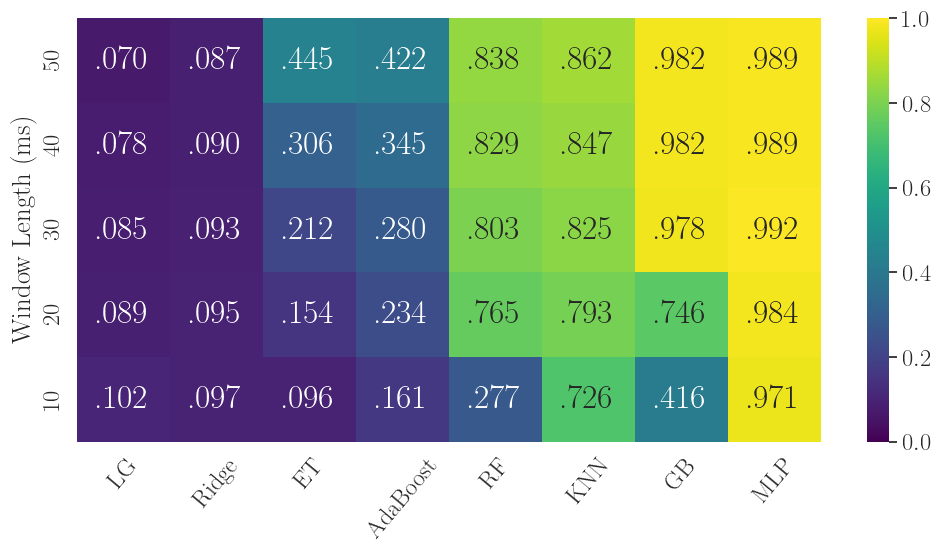

In [22]:
# Set the figure size
plt.figure(figsize=(12, 5.5))  # Width x Height in inches

# Create the heatmap
ax = sns.heatmap(
    heatmap_mean,
    cmap="viridis",
    annot=heatmap_mean.map(format_func),  # Apply formatting function
    fmt="",
    vmin=0.0,
    vmax=1.0,  # Set vmin and vmax for better color scaling
    annot_kws={"fontsize": 24},
)
ax.set_ylabel("Window Length (ms)")
ax.set_xlabel("")
plt.xticks(rotation=50)

# Display the plot with a title
plt.savefig("heatmap_fault_class.svg", bbox_inches="tight", dpi=300)
plt.show()

## FAULT_LOCATION

In [23]:
models_to_exclude = ["sgd_regressor", "linear_regression", "linear_svr", "ridge"]

# convert to abbreviated model name using the model_map
models_to_exclude = [model_map.get(model, model) for model in models_to_exclude]
print(f"Models to exclude: {models_to_exclude}")

Models to exclude: ['SGD', 'LR', 'SVR', 'Ridge']


In [24]:
# Create a pivot table for the heatmap
heatmap_data_localization = regression_runs.pivot_table(
    index="window_length",
    columns="model",
    values="mean_r2",
    aggfunc="max",
)

# Sort the pivot table by window_length in descending order
heatmap_data_localization = heatmap_data_localization.sort_index(ascending=False)
# Sort the columns by the average of each column in ascending order
heatmap_data_localization = heatmap_data_localization.reindex(
    sorted(
        heatmap_data_localization.columns,
        key=lambda x: heatmap_data_localization[x].mean(),
    ),
    axis=1,
)

# Remove models that are in the exclusion list (using the map function)
heatmap_data_localization = heatmap_data_localization.loc[
    :, ~heatmap_data_localization.columns.isin(models_to_exclude)
]

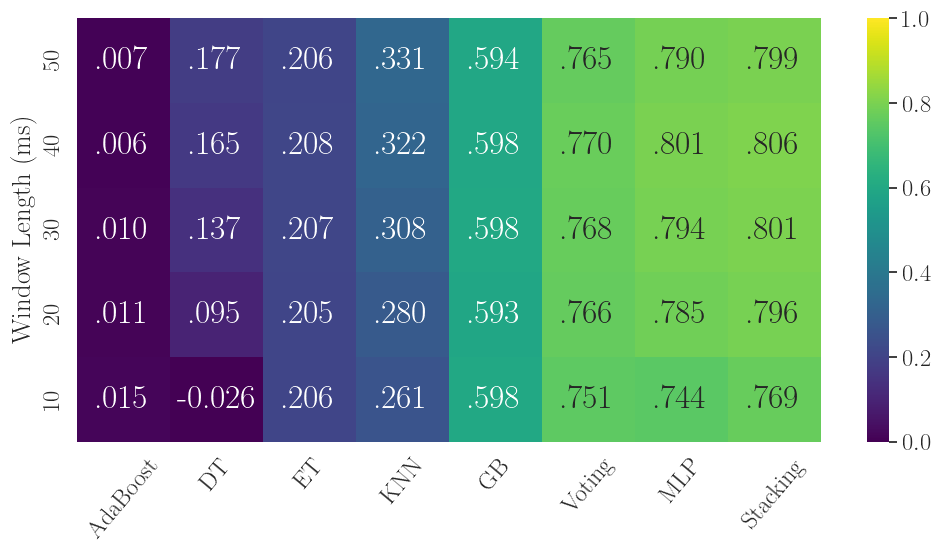

In [25]:
# Set the figure size
plt.figure(figsize=(12, 5.5))  # Width x Height in inches


# Create the heatmap
ax = sns.heatmap(
    heatmap_data_localization,
    cmap="viridis",
    annot=heatmap_data_localization.map(format_func),  # Apply formatting function
    fmt="",
    vmin=0.0,
    vmax=1.0,  # Set vmin and vmax for better color scaling
    annot_kws={"fontsize": 24},
)

ax.set_ylabel("Window Length (ms)")
ax.set_xlabel("")
# rotate x labels
plt.xticks(rotation=50)

# Display the plot with a title
plt.savefig("heatmap_fault_localization.svg", bbox_inches="tight", dpi=300)
plt.show()

In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# Load the runtime results
model_runtimes = pd.read_csv(
    r"C:\Users\user\Repositories\fault-classification-localization\outputs\run_time_results\model_runtimes.csv"
)

# Sort the DataFrame from slowest to fastest based on mean_runtime
sorted_runtimes = model_runtimes.sort_values(by="mean_runtime_ms", ascending=False)
sorted_runtimes

,model,mean_runtime_ms,std_runtime_ms
5,k_neighbors_regressor,1287.531560,36.628565
3,stacking_regressor,2.945308,1.623497
4,voting_regressor,2.879321,1.062109
10,extra_trees_regressor,1.635337,0.290198
6,hist_gradient_boosting_regressor,1.226146,0.331548
8,ada_boost_regressor,1.207314,0.400685
7,mlp_regressor,0.563421,0.466856
9,decision_tree_regressor,0.043530,0.052169
0,linear_svr,0.036975,0.018063
2,sgd_regressor,0.034425,0.016448


In [27]:
# ada_boost_regressor -> AdaBoost
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace(
    "ada_boost_regressor", "AdaBoost"
)
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace("sgd_regressor", "SGD")
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace(
    "linear_svr", "LinearSVR"
)
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace("mlp_regressor", "MLP")
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace(
    "hist_gradient_boosting_regressor", "GB"
)
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace(
    "k_neighbors_regressor", "KNN"
)
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace(
    "voting_regressor", "Voting"
)
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace(
    "stacking_regressor", "Stacking"
)
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace("ridge", "Ridge")
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace(
    "decision_tree_regressor", "DT"
)
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace(
    "extra_trees_regressor", "ET"
)
sorted_runtimes["model"] = sorted_runtimes["model"].str.replace(
    "linear_regression", "LR"
)


# remove "sgd_regressor"
sorted_runtimes = sorted_runtimes[~sorted_runtimes["model"].str.contains("SGD")]
# remove "AdaBoost"
sorted_runtimes = sorted_runtimes[~sorted_runtimes["model"].str.contains("AdaBoost")]

In [28]:
sorted_runtimes

,model,mean_runtime_ms,std_runtime_ms
5,KNN,1287.531560,36.628565
3,Stacking,2.945308,1.623497
4,Voting,2.879321,1.062109
10,ET,1.635337,0.290198
6,GB,1.226146,0.331548
7,MLP,0.563421,0.466856
9,DT,0.043530,0.052169
0,LinearSVR,0.036975,0.018063
1,Ridge,0.033129,0.014489
11,LR,0.030643,0.023748


In [29]:
r2_scores_fault_localization = pd.DataFrame(heatmap_data_localization.loc[10])
r2_scores_fault_localization = r2_scores_fault_localization.sort_values(
    "model", ascending=True
)
# remove "SGD" and "AdaBoost"
r2_scores_fault_localization = r2_scores_fault_localization[
    ~r2_scores_fault_localization.index.str.contains("SGD")
]
r2_scores_fault_localization = r2_scores_fault_localization[
    ~r2_scores_fault_localization.index.str.contains("AdaBoost")
]
# remove "LR" and "LinearSVR"
r2_scores_fault_localization = r2_scores_fault_localization[
    ~r2_scores_fault_localization.index.str.contains("LR")
]
r2_scores_fault_localization = r2_scores_fault_localization[
    ~r2_scores_fault_localization.index.str.contains("LinearSVR")
]
# remove "Ridge"
r2_scores_fault_localization = r2_scores_fault_localization[
    ~r2_scores_fault_localization.index.str.contains("Ridge")
]

r2_scores_fault_localization

,10
model,
DT,-0.025750
ET,0.205641
GB,0.597943
KNN,0.260779
MLP,0.743887
Stacking,0.769081
Voting,0.750622


In [30]:
# remove "LR" and "LinearSVR"
sorted_runtimes = sorted_runtimes[
    ~sorted_runtimes["model"].str.contains("LR")
    & ~sorted_runtimes["model"].str.contains("LinearSVR")
    & ~sorted_runtimes["model"].str.contains("Ridge")
]

In [31]:
r2_scores_fault_localization

,10
model,
DT,-0.025750
ET,0.205641
GB,0.597943
KNN,0.260779
MLP,0.743887
Stacking,0.769081
Voting,0.750622


In [32]:
sorted_runtimes = sorted_runtimes.sort_values(by="model", ascending=True)
sorted_runtimes["r2_score"] = r2_scores_fault_localization.values
sorted_runtimes = sorted_runtimes.sort_values(by="mean_runtime_ms", ascending=False)
sorted_runtimes

,model,mean_runtime_ms,std_runtime_ms,r2_score
5,KNN,1287.531560,36.628565,0.260779
3,Stacking,2.945308,1.623497,0.769081
4,Voting,2.879321,1.062109,0.750622
10,ET,1.635337,0.290198,0.205641
6,GB,1.226146,0.331548,0.597943
7,MLP,0.563421,0.466856,0.743887
9,DT,0.043530,0.052169,-0.025750


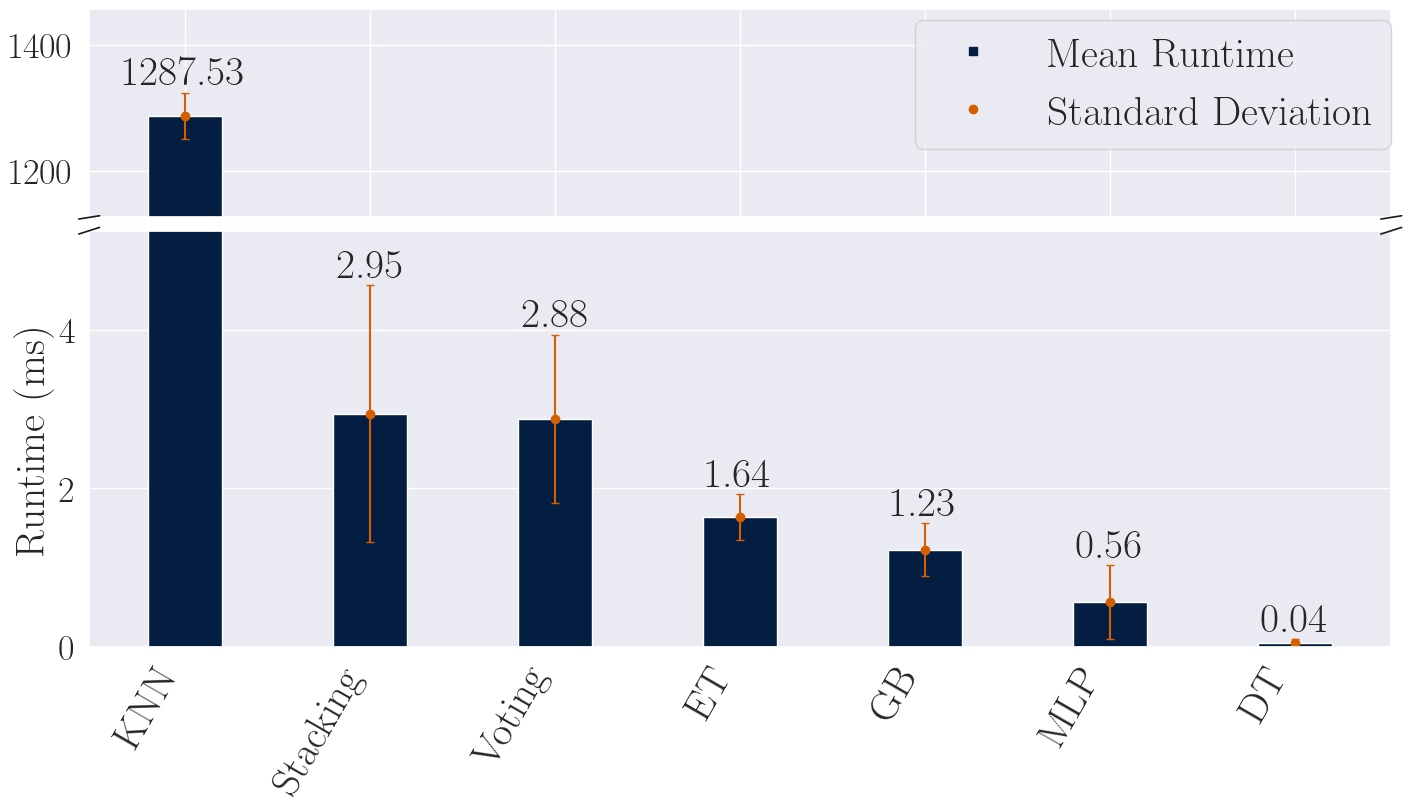

In [33]:
import numpy as np
import matplotlib.pyplot as plt


def plot_broken_axis_runtimes(
    df,
    mean_col="mean_runtime_ms",
    std_col="std_runtime_ms",
    label_col="model",
    filename="overview_runtime_ml_models_broken.pdf",
    bar_width=0.4,
    small_padding=0.15,  # % headroom above small bars (incl. std)
    big_padding=0.10,  # % headroom above the big bar (incl. std)
    gap_ratio=0.85,  # lower bound of top axis starts at gap_ratio * big_upper
    label_rotation=60,
    fontsize_ticks=30,
    fontsize_label=30,
    fontsize_legend=30,
    annotate=True,
):
    """
    Create a broken y-axis bar chart for runtimes with error bars.
    Assumes df is a pandas DataFrame with columns for mean, std, and label.
    """
    means = np.asarray(df[mean_col], dtype=float)
    stds = np.asarray(df[std_col], dtype=float)
    labels = list(df[label_col])

    x = np.arange(len(df))

    # Sanity checks
    if len(means) == 0:
        raise ValueError("No data to plot.")
    if len(stds) != len(means) or len(labels) != len(means):
        raise ValueError("mean/std/label columns must have the same length.")

    # We'll consider error bars for bounds
    upper_vals = means + np.nan_to_num(stds, nan=0.0)

    # Identify the largest bar (candidate for the top axis)
    big_idx = int(np.argmax(upper_vals))
    big_upper = upper_vals[big_idx]  # mean + std for the largest bar

    # Determine the maximum among the "small" bars (those not the largest)
    if len(upper_vals) > 1:
        small_mask = np.ones_like(upper_vals, dtype=bool)
        small_mask[big_idx] = False
        small_upper = np.max(upper_vals[small_mask])
    else:
        # Only one bar: no real "break" needed, but we can still show a single axis.
        small_upper = 0.0

    # Compute axis limits
    # Bottom axis shows small bars up to a padded small_upper
    ax2_ymax = small_upper * (1 + small_padding) if small_upper > 0 else big_upper * 0.2
    ax2_ymin = 0.0

    # Top axis zooms into the big one (or any above the bottom cap)
    ax1_ymin = max(big_upper * gap_ratio, ax2_ymax * 1.05)  # ensure a visual gap
    ax1_ymax = big_upper * (1 + big_padding)

    # Create two vertically stacked plots sharing the x-axis
    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        sharex=True,
        figsize=(14, 8),
        gridspec_kw={"height_ratios": [1, 2]},
        constrained_layout=True,
    )

    # Plot on both axes
    bar_color = "#041E42"
    err_color = "#D55E00"

    bars1 = ax1.bar(x, means, width=bar_width, color=bar_color)
    err1 = ax1.errorbar(x, means, yerr=stds, fmt="o", color=err_color, capsize=3)

    bars2 = ax2.bar(x, means, width=bar_width, color=bar_color)
    err2 = ax2.errorbar(x, means, yerr=stds, fmt="o", color=err_color, capsize=3)

    # Axis limits
    # If there's effectively no outlier, fall back to a single-axis feel by expanding ax2
    if small_upper == 0 or big_upper <= ax2_ymax * 1.05:
        # No meaningful break – show everything in the bottom axis
        ax1.set_visible(False)
        ax2.set_ylim(ax2_ymin, big_upper * (1 + small_padding))
    else:
        ax1.set_ylim(ax1_ymin, ax1_ymax)
        ax2.set_ylim(ax2_ymin, ax2_ymax)

        # Draw diagonal break marks
        d = 0.008  # size of diagonal lines
        kwargs = dict(
            color="k",
            clip_on=False,
            linewidth=1.2,
            zorder=10,  # ensure break marks are on top
        )

        # Top axis diagonals (bottom of ax1)
        ax1.plot((-d, +d), (-d, +d), transform=ax1.transAxes, **kwargs)
        ax1.plot((1 - d, 1 + d), (-d, +d), transform=ax1.transAxes, **kwargs)

        # Bottom axis diagonals (top of ax2)
        ax2.plot((-d, +d), (1 - d, 1 + d), transform=ax2.transAxes, **kwargs)
        ax2.plot((1 - d, 1 + d), (1 - d, 1 + d), transform=ax2.transAxes, **kwargs)

    # Labels, ticks, and grid
    ax2.set_ylabel("Runtime (ms)", fontsize=fontsize_label)
    plt.xticks(x, labels, rotation=label_rotation, ha="right", fontsize=fontsize_ticks)
    ax2.tick_params(axis="y", labelsize=fontsize_ticks - 4)
    ax1.tick_params(axis="y", labelsize=fontsize_ticks - 4)
    ax2.grid(axis="x")

    # Annotate (mean values) on the appropriate axis (skip if they would be outside)
    if annotate:
        for i, (m, s, up) in enumerate(zip(means, stds, upper_vals)):
            if ax1.get_visible() and up >= ax1.get_ylim()[0]:
                target_ax = ax1
            else:
                target_ax = ax2
            # Only place the label if it fits within the axis limits
            ylim = target_ax.get_ylim()
            label_y = m + (s if np.isfinite(s) else 0.0)
            if ylim[0] <= label_y <= ylim[1]:
                target_ax.text(
                    i,
                    label_y,
                    f"{m:.2f}",
                    ha="center",
                    va="bottom",
                    fontsize=fontsize_ticks,
                )

    # Single legend for the whole figure
    handles = [
        plt.Line2D(
            [0], [0], marker="s", linestyle="", color=bar_color, label="Mean Runtime"
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            linestyle="",
            color=err_color,
            label="Standard Deviation",
        ),
    ]
    fig.legend(handles=handles, loc="upper right", fontsize=fontsize_legend)

    # Make sure long labels aren't cut
    # (constrained_layout is on; bbox_inches="tight" helps at save time)
    plt.savefig(filename, bbox_inches="tight")
    # plt.show()


# ===== Usage =====
# Assumes you have a pandas DataFrame `sorted_runtimes` with columns:
#   "model", "mean_runtime_ms", "std_runtime_ms"
plot_broken_axis_runtimes(sorted_runtimes)

In [ ]:
# print cpu info
import platform

print("CPU Info:", platform.processor())
print("Platform Info:", platform.platform())


CPU Info: Intel64 Family 6 Model 191 Stepping 2, GenuineIntel
Platform Info: Windows-11-10.0.26200-SP0
